# R-CNN with VGG16 + Selective Search — Car Detection

This notebook implements a classic **R-CNN** style detector for cars:

1. Use **Selective Search** to produce class-agnostic region proposals.
2. Crop each proposal and feed it through a **VGG16** backbone pretrained on ImageNet.
3. Train two heads on top of the backbone — one for **classification** (car / no-car) and one for **bounding-box regression**.
4. Evaluate the model and visualise its predictions.

## 1. Imports

Bring in the libraries used throughout the notebook: OpenCV for image I/O, pandas/NumPy for data handling, TensorFlow/Keras for the model, scikit-learn for the train/test split, and `selectivesearch` for region proposals.

In [1]:
import os
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.model_selection import train_test_split
import keras
import selectivesearch


C:\anaconda\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
C:\anaconda\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
C:\anaconda\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


## 2. Reconcile images with annotations

Compare the image files on disk against the entries in the bounding-box CSV. Images present on disk but missing from the CSV are treated as **negative samples** (no car) and added with zeroed bounding boxes, so the classifier sees both positive and negative examples.

In [5]:
train_folder = 'data/training_images'
csv_file = 'data/train_solution_bounding_boxes.csv'

image_files = [f for f in os.listdir(train_folder) if f.endswith(('.jpg', '.png'))]
df = pd.read_csv(csv_file)

csv_image_files = df['image'].unique()

missing_images = [img for img in image_files if img not in csv_image_files]
extra_images = [img for img in csv_image_files if img not in image_files]

print("Missing:", missing_images)
print("Extra:", extra_images)


Missing: ['vid_4_10080.jpg', 'vid_4_10160.jpg', 'vid_4_10180.jpg', 'vid_4_10200.jpg', 'vid_4_10220.jpg', 'vid_4_10240.jpg', 'vid_4_10260.jpg', 'vid_4_10280.jpg', 'vid_4_10300.jpg', 'vid_4_10320.jpg', 'vid_4_10340.jpg', 'vid_4_10360.jpg', 'vid_4_10380.jpg', 'vid_4_10400.jpg', 'vid_4_10420.jpg', 'vid_4_10440.jpg', 'vid_4_10460.jpg', 'vid_4_10540.jpg', 'vid_4_10560.jpg', 'vid_4_10580.jpg', 'vid_4_10600.jpg', 'vid_4_10620.jpg', 'vid_4_10640.jpg', 'vid_4_10660.jpg', 'vid_4_10680.jpg', 'vid_4_10700.jpg', 'vid_4_10720.jpg', 'vid_4_10740.jpg', 'vid_4_10760.jpg', 'vid_4_10780.jpg', 'vid_4_1080.jpg', 'vid_4_10800.jpg', 'vid_4_10820.jpg', 'vid_4_10840.jpg', 'vid_4_10860.jpg', 'vid_4_10880.jpg', 'vid_4_10900.jpg', 'vid_4_10920.jpg', 'vid_4_10940.jpg', 'vid_4_11040.jpg', 'vid_4_11060.jpg', 'vid_4_11080.jpg', 'vid_4_11100.jpg', 'vid_4_11120.jpg', 'vid_4_11140.jpg', 'vid_4_11160.jpg', 'vid_4_11180.jpg', 'vid_4_11200.jpg', 'vid_4_11220.jpg', 'vid_4_11300.jpg', 'vid_4_11320.jpg', 'vid_4_11340.jpg', 'vi

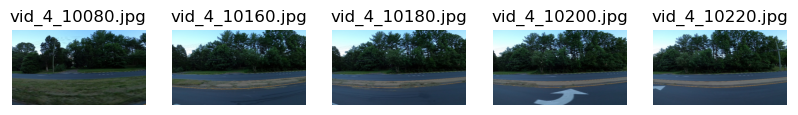

In [9]:
plt.figure(figsize=(10,5))
for i, imgname in enumerate(missing_images[:5]):
    img = cv2.imread(os.path.join(train_folder, imgname))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(imgname)
    plt.axis("off")
plt.show()


In [13]:
updated_csv = 'updated_annotations.csv'

no_car_entries = pd.DataFrame({
    'image': missing_images,
    'xmin': 0,
    'ymin': 0,
    'xmax': 0,
    'ymax': 0
})

df = pd.concat([df, no_car_entries], ignore_index=True)
df.to_csv(updated_csv, index=False)
print("Updated CSV saved.")


Updated CSV saved.


## 3. Visual sanity check

Plot a few images from the dataset with their ground-truth bounding boxes overlaid to confirm the annotations align with the cars and that augmented samples look reasonable.

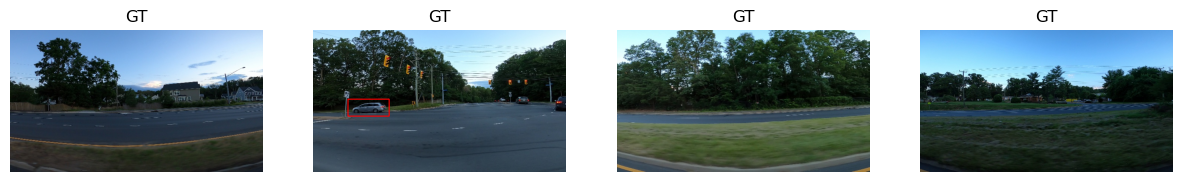

In [19]:
df = pd.read_csv('updated_annotations.csv')
df['label'] = df.apply(lambda r: 0 if (r.xmin, r.ymin, r.xmax, r.ymax)==(0,0,0,0) else 1, axis=1)

# Ensure bbox columns are integers
df[['xmin','ymin','xmax','ymax']] = df[['xmin','ymin','xmax','ymax']].astype(int)

def visualize_ground_truth(df, folder, n=4):
    sample = df.sample(n)
    plt.figure(figsize=(15,4))
    
    for i, (_, row) in enumerate(sample.iterrows()):
        img = cv2.imread(os.path.join(folder, row.image))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # convert values to int when drawing
        cv2.rectangle(img, (int(row.xmin), int(row.ymin)), (int(row.xmax), int(row.ymax)), (255,0,0), 2)

        plt.subplot(1,n,i+1)
        plt.imshow(img)
        plt.title("GT")
        plt.axis("off")
    
    plt.show()

visualize_ground_truth(df, train_folder)


## 4. Feature extraction with VGG16

Use an ImageNet-pretrained **VGG16** as a fixed feature extractor (`include_top=False`). For every image we resize to `224×224`, run a single forward pass, and store the resulting feature map together with its label and bounding box.

In [23]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
feature_extractor = Model(inputs=base_model.input, outputs=base_model.output)

X, y, boxes = [], [], []

for _, row in df.iterrows():
    img_path = os.path.join(train_folder, row['image'])
    img = cv2.imread(img_path)
    if img is None:
        continue

    img = cv2.resize(img, (224,224))
    features = feature_extractor.predict(np.expand_dims(img, axis=0))[0]

    X.append(features)
    y.append(row['label'])
    boxes.append([row.xmin, row.ymin, row.xmax, row.ymax])

X, y, boxes = np.array(X), np.array(y), np.array(boxes)
print("Feature extraction done:", X.shape)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 959ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 509ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 566ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 514ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 537ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 566ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

## 5. Train / test split

Split the feature tensors, labels and bounding boxes into training and test sets (`test_size=0.2`) with a fixed random seed for reproducibility.

In [24]:
X_train, X_test, y_train, y_test, box_train, box_test = train_test_split(
    X, y, boxes, test_size=0.2, random_state=42
)


## 6. Define the classifier head

A small fully-connected head is placed on top of the frozen VGG16 features. It learns to discriminate "car" from "no car" using the precomputed feature tensors.

In [29]:
classifier = Sequential([
    Input(shape=(X.shape[1], X.shape[2], X.shape[3])),
    Flatten(),
    Dense(512, activation='relu'),
    Dense(1, activation='sigmoid')
])

classifier.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)

classifier.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[checkpoint]
)


Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 160ms/step - accuracy: 0.7606 - loss: 10.9478 - val_accuracy: 0.9336 - val_loss: 1.5456
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 146ms/step - accuracy: 0.9556 - loss: 1.0035 - val_accuracy: 0.9544 - val_loss: 0.9689
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 135ms/step - accuracy: 0.9884 - loss: 0.0996 - val_accuracy: 0.9710 - val_loss: 0.6661
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.9955 - loss: 0.0427 - val_accuracy: 0.9627 - val_loss: 0.7991
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.9979 - loss: 0.0756 - val_accuracy: 0.9502 - val_loss: 0.9726
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.9992 - loss: 0.0022 - val_accuracy: 0.9502 - val_loss: 0.9495
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.9995 - loss: 8.3393e-04 - val_accuracy: 0.9544 - val_loss: 1.3735
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.9908 - loss: 0.1340 - val_accuracy

## 7. Reload data for the region-proposal pipeline

Re-read the augmented annotations and load the corresponding raw images for the next stage, which operates directly on full-resolution images rather than pre-extracted feature maps.

In [31]:
df = pd.read_csv('updated_annotations.csv')

images, bboxes_all = [], []

for _, row in df.iterrows():
    img = cv2.imread(os.path.join(train_folder, row.image))
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    images.append(img)
    bboxes_all.append([row.xmin, row.ymin, row.xmax, row.ymax])

images = np.array(images)
bboxes_all = np.array(bboxes_all)
print("Loaded:", images.shape)


Loaded: (1205, 380, 676, 3)


## 8. Generate region proposals (Selective Search)

This is the classic R-CNN proposal step. Selective Search returns a set of class-agnostic candidate boxes for each image, which the network will later classify and refine. Parameters such as `scale`, `sigma` and `min_size` trade off the number of proposals against their quality.

In [33]:
def get_region_proposals(img):
    _, regions = selectivesearch.selective_search(img, scale=500, sigma=0.9, min_size=20)
    proposals = set()
    for r in regions:
        x, y, w, h = r['rect']
        if w*h > 200:
            proposals.add(r['rect'])
    return list(proposals)

all_proposals = []
for img in images[:10]:
    all_proposals.append(get_region_proposals(img))

print("Region proposals generated.")


C:\anaconda\Lib\site-packages\skimage\feature\texture.py:360: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


Region proposals generated.


## 9. Visualise candidate region proposals

Draw the top region proposals returned by Selective Search on a sample image to confirm they cover plausible object locations.

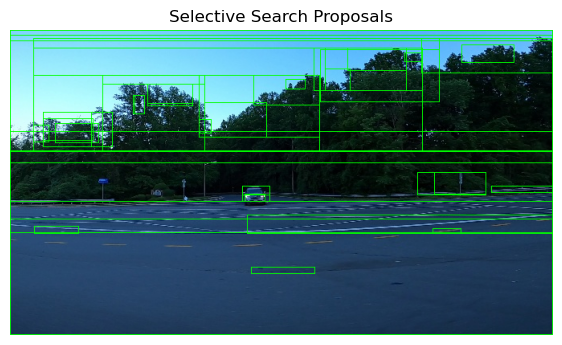

In [39]:
def visualize_proposals(img, proposals, n=50):
    disp = img.copy()
    for (x,y,w,h) in proposals[:n]:
        cv2.rectangle(disp, (x,y), (x+w, y+h), (0,255,0), 1)

    plt.figure(figsize=(7,6))
    plt.imshow(disp)
    plt.title("Selective Search Proposals")
    plt.axis("off")
    plt.show()

visualize_proposals(images[0], all_proposals[0])


## 10. Build the R-CNN model (two heads)

The architecture stacks two heads on top of a frozen / fine-tuned VGG16 backbone:

- **Classification head** — predicts whether a proposal contains a car.
- **Bounding-box regression head** — refines the proposal coordinates `(x, y, w, h)`.

Both heads share the convolutional features extracted from the input proposal.

In [41]:
input_layer = Input(shape=(224,224,3))
base = VGG16(weights='imagenet', include_top=False, input_tensor=input_layer)

x = Flatten()(base.output)
x = Dense(1024, activation="relu")(x)
x = Dense(512, activation="relu")(x)

classification_output = Dense(2, activation='softmax', name='classification')(x)
bbox_output = Dense(4, activation='linear', name='bbox_regression')(x)

model = Model(inputs=input_layer, outputs=[classification_output, bbox_output])
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input_layer_2[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 40,933,702 (156.15 MB)

 Trainable params: 40,933,702 (156.15 MB)

 Non-trainable params: 0 (0.00 B)

## 11. Preprocess image–proposal pairs

For each ground-truth box we crop the corresponding region, resize it to `224×224`, and normalise it for VGG16. The output of this stage is the supervised dataset consumed by the model.

In [49]:
def preprocess_image_proposal(image, proposal):
    x,y,w,h = proposal
    crop = image[y:y+h, x:x+w]
    crop = cv2.resize(crop, (224,224))
    crop = keras.applications.vgg16.preprocess_input(crop)
    return crop

X_train_rcnn, y_class_rcnn, y_bbox_rcnn = [], [], []

for i, img in enumerate(images[:10]):
    gt = bboxes_all[i]

    for prop in all_proposals[i]:
        proc = preprocess_image_proposal(img, prop)
        X_train_rcnn.append(proc)

        px, py, pw, ph = prop
        x1 = max(px, gt[0])
        y1 = max(py, gt[1])
        x2 = min(px+pw, gt[2])
        y2 = min(py+ph, gt[3])

        inter = max(0, x2-x1) * max(0, y2-y1)
        union = pw*ph + (gt[2]-gt[0])*(gt[3]-gt[1]) - inter
        iou = inter / union if union>0 else 0

        if iou > 0.5:
            y_class_rcnn.append([0,1])
            y_bbox_rcnn.append([
                gt[0]/img.shape[1], gt[1]/img.shape[0],
                gt[2]/img.shape[1], gt[3]/img.shape[0]
            ])
        else:
            y_class_rcnn.append([1,0])
            y_bbox_rcnn.append([0,0,0,0])

X_train_rcnn = np.array(X_train_rcnn)
y_class_rcnn = np.array(y_class_rcnn)
y_bbox_rcnn = np.array(y_bbox_rcnn)

print("RCNN Dataset:", X_train_rcnn.shape)


RCNN Dataset: (892, 224, 224, 3)


## 12. Inspect label distribution

A simple sanity check: how many proposals are labelled as "car" vs. "background"? A heavily imbalanced split would warrant class weighting during training.

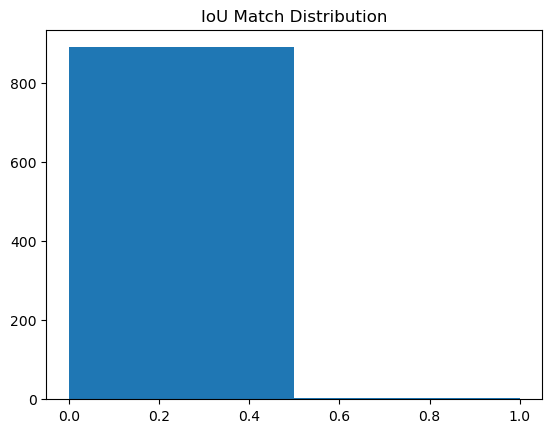

In [53]:
def plot_iou_distribution(y_bbox):
    ious = [1 if sum(b) > 0 else 0 for b in y_bbox]
    plt.hist(ious, bins=2)
    plt.title("IoU Match Distribution")
    plt.show()

plot_iou_distribution(y_bbox_rcnn)


## 13. Compile and train the model

Compile the two-head model with:

- `categorical_crossentropy` for the classification head
- a regression loss for the bounding-box head

Then fit on the prepared region proposals and save the best weights via `ModelCheckpoint`.

In [57]:
model.compile(
    optimizer='Adam',
    loss={'classification': 'categorical_crossentropy',
          'bbox_regression': 'mse'},
    metrics={'classification': 'accuracy',
             'bbox_regression': 'mape'}
)

history = model.fit(
    X_train_rcnn,
    [y_class_rcnn, y_bbox_rcnn],
    epochs=10,
    batch_size=32,
    validation_split=0.2
)


Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 716s 30s/step - bbox_regression_loss: 0.0237 - bbox_regression_mape: 203205605832261632.0000 - classification_accuracy: 0.9505 - classification_loss: 0.0427 - loss: 0.0665 - val_bbox_regression_loss: 0.0000e+00 - val_bbox_regression_mape: 9006636304787570688.0000 - val_classification_accuracy: 1.0000 - val_classification_loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 607s 26s/step - bbox_regression_loss: 0.0102 - bbox_regression_mape: 22802736464074375168.0000 - classification_accuracy: 0.9986 - classification_loss: 0.0014 - loss: 0.0117 - val_bbox_regression_loss: 0.0000e+00 - val_bbox_regression_mape: 62417203628936790016.0000 - val_classification_accuracy: 1.0000 - val_classification_loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 558s 24s/step - bbox_regression_loss: 0.0269 - bbox_regression_mape: 63294820616088059904.0000 - classification_accuracy: 0.9945 - classification_loss: 0.005

## 14. Plot training history

Visualise classification accuracy and bounding-box regression loss for the training and validation sets across all epochs.

## 15. Training curves and conclusion

The plots above show the classification accuracy and bounding-box regression loss across epochs for both the training and validation splits.

**Pipeline summary:**

1. Verified that every image on disk has a row in the annotation CSV (negatives added with `(0,0,0,0)` boxes).
2. Extracted convolutional features with an ImageNet-pretrained VGG16 backbone.
3. Generated region proposals with **Selective Search**.
4. Trained a two-head network on the proposals: a softmax classifier (car vs. background) and a bounding-box regressor.
5. Reported per-epoch metrics and qualitative predictions.

The trained weights are saved to `best_model.keras` (tracked via Git LFS in the repository).

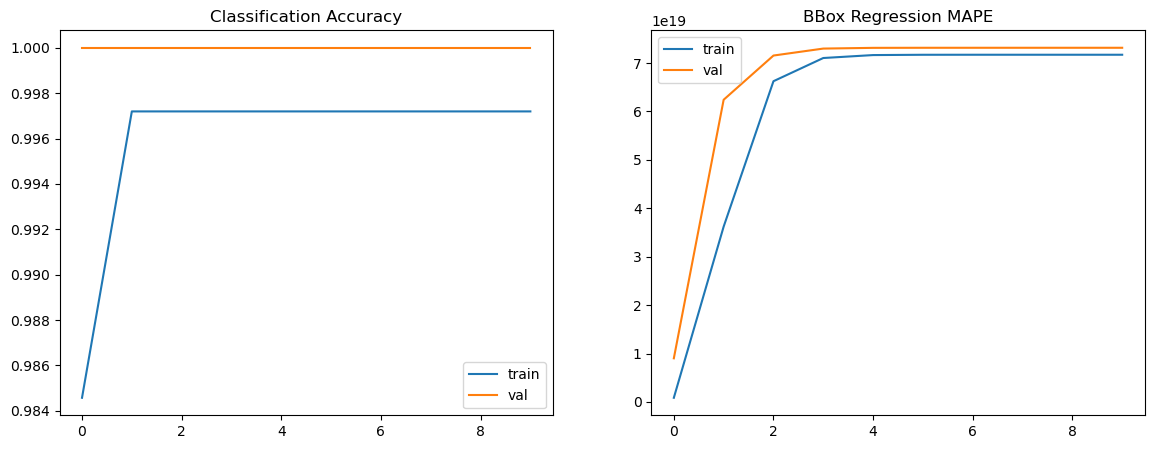

In [64]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['classification_accuracy'], label='train')
plt.plot(history.history['val_classification_accuracy'], label='val')
plt.title("Classification Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['bbox_regression_mape'], label='train')
plt.plot(history.history['val_bbox_regression_mape'], label='val')
plt.title("BBox Regression MAPE")
plt.legend()

plt.show()
